$$ ITI \space AI-Pro: \space Intake \space 45 $$
$$ Machine \space Learning \space 1 $$
$$ Lab \space no. \space 4 $$

# `01` Import Necessary Libraries

## `i` Default Libraries

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## `ii` Additional Libraries
Add imports for additional libraries you used throughout the notebook

In [4]:
import warnings
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import QuantileTransformer,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,f1_score,confusion_matrix,classification_report
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
warnings.filterwarnings("ignore")


----------------------------

# `02` Load Data

Note: Make sure the `Data` folder attached with the notebook is in the same path for this cell to work properly.

[Dataset Link](https://www.kaggle.com/datasets/parisrohan/credit-score-classification)

In [5]:
# prompt: connect with drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
train = pd.read_csv("/content/drive/MyDrive/credit_data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/credit_data/test.csv")

In [7]:
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [8]:
train.shape

(100000, 28)

In [9]:
test.shape

(50000, 27)

----------------

# `03` Exploratory Data Analysis (EDA)

## `i` Simple Analysis

Preview data, perform statistical data analysis and explore as much as needed to better understand the data set we're dealing with.

`Notes:`
- Feel free to look up EDA approaches online for inspiration (however you **must understand** everything and not copy paste).
- Make sure to add notes and insights extracted from your analysis.


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [11]:
train.shape

(100000, 28)

In [12]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


### there are missing value will prepare it in preparation stage

In [13]:
train.duplicated().sum()

0

In [14]:
train['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [15]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


----------------

# `03` Data Preparation

Perform data cleaning, feature engineering, scaling, dropping unwanted columns (such as IDs), etc. as needed to make sure it's ready for the model.

`Q` Is this dataset *skewed*?

Hint: It could be helpful to check `sklearn.preprocessing` module.

In [16]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [17]:
train['Month'].value_counts()

,count
Month,
January,12500
February,12500
March,12500
April,12500
May,12500
June,12500
July,12500
August,12500


# Data Spliting

In [18]:
fin_train,fin_val=train_test_split(train,test_size=0.2,random_state=1234)

# Occupation column

In [19]:
fin_train['Occupation'].value_counts()

,count
Occupation,
_______,5663
Lawyer,5268
Architect,5124
Scientist,5047
Engineer,5027
Teacher,5021
Mechanic,5014
Accountant,4999
Developer,4981


In [20]:
fin_train['Occupation'] = fin_train['Occupation'].replace("-------", np.nan)


In [21]:
encoder = LabelEncoder()
fin_train['Occupation'] = encoder.fit_transform(fin_train['Occupation'].astype(str))

In [22]:
Occup_impute=KNNImputer()
fin_train['Occupation']=Occup_impute.fit_transform(fin_train[['Occupation']])

In [23]:
fin_train['Occupation'].value_counts()

,count
Occupation,
15.0,5663
7.0,5268
1.0,5124
12.0,5047
4.0,5027
13.0,5021
9.0,5014
0.0,4999
2.0,4981


In [24]:
fin_val['Occupation'] = fin_val['Occupation'].replace("-------", np.nan)
fin_val['Occupation'] = encoder.transform(fin_val['Occupation'].astype(str))
fin_val['Occupation']=Occup_impute.transform(fin_val[['Occupation']])

# Age column

In [25]:
fin_train['Age'] = fin_train['Age'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_train['Age']=fin_train['Age'].astype(int)

In [26]:
fin_train['Age'].dtype

dtype('int64')

In [27]:
fin_train['Age'] = fin_train['Age'].apply(lambda row: np.nan if (row <0) | (row >=65)  else row)

In [28]:
Age_impute=KNNImputer()
fin_train['Age']=Age_impute.fit_transform(fin_train[['Age']])

In [29]:
train['Age'].describe()

,Age
count,100000
unique,1788
top,38
freq,2833


In [30]:
fin_val['Age'] = fin_val['Age'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Age']=fin_val['Age'].astype(int)
fin_val['Age'] = fin_val['Age'].apply(lambda row: np.nan if (row <0) | (row >=65)  else row)
fin_val['Age']=Age_impute.transform(fin_val[['Age']])

# Annual_Income Column

In [31]:
print(list(train['Annual_Income'].unique()))



['19114.12', '34847.84', '34847.84_', '143162.64', '30689.89', '30689.89_', '35547.71_', '35547.71', '73928.46', '131313.4', '10909427.0', '34081.38_', '34081.38', '114838.41', '114838.41_', '31370.8', '33751.27', '88640.24', '88640.24_', '54392.16', '54392.16_', '8701.545', '8701.545_', '25546.26', '25546.26_', '31993.78', '92047.08', '92047.08_', '32284.62', '97791.42', '97791.42_', '19300.34', '19514.88', '10183.015', '10183.015_', '106733.13', '106733.13_', '12600.445', '12600.445_', '57983.12', '57983.12_', '20787.69', '34290.12', '34290.12_', '43070.24', '43070.24_', '28572.39', '6515990.0_', '39641.54', '39641.54_', '20186.02', '586359.0', '18627.64', '12986.745', '58317.0', '42171.98', '71681.4', '29469.98', '29469.98_', '72559.36', '15566.02', '15566.02_', '66567.32', '12909.895', '30788.44', '20574.47', '20574.47_', '148699.32', '148699.32_', '85554.03', '55829.79', '18334118.0', '19717385.0', '14165.23', '14165.23_', '87215.68', '2709655.0', '81842.28', '81842.28_', '95956.5

In [32]:
x='65000.73_'
x[-1]

'_'

In [33]:
train['Annual_Income'].dtype

dtype('O')

In [34]:

fin_train['Annual_Income'] = fin_train['Annual_Income'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)


In [35]:
fin_train['Annual_Income']=fin_train['Annual_Income'].astype(float)

In [36]:
fin_train['Annual_Income'].dtype

dtype('float64')

In [37]:
fin_train['Annual_Income'].isna().sum()

0

In [38]:
fin_val['Annual_Income'] = fin_val['Annual_Income'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Annual_Income']=fin_val['Annual_Income'].astype(float)

# Monthly_Inhand_Salary column

In [39]:
fin_train['Monthly_Inhand_Salary'].dtype

dtype('float64')

In [40]:
fin_train['Monthly_Inhand_Salary'].fillna(fin_train['Monthly_Inhand_Salary'].mean(),inplace=True)

In [41]:
fin_train['Monthly_Inhand_Salary'].isna().sum()

0

In [42]:
fin_val['Monthly_Inhand_Salary'].fillna(fin_train['Monthly_Inhand_Salary'].mean(),inplace=True)

# Num_Bank_Accounts column

In [43]:

fin_train['Num_Bank_Accounts'].dtype


dtype('int64')

In [44]:
fin_train['Num_Bank_Accounts'].describe()

,Num_Bank_Accounts
count,80000.000000
mean,17.265037
std,118.894881
min,-1.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,1798.000000


In [45]:
fin_train['Num_Bank_Accounts'].isna().sum()

0

In [46]:
fin_train['Num_Bank_Accounts'] = fin_train['Num_Bank_Accounts'].apply(lambda x: abs(x) if x<0 else x)

In [47]:
fin_val['Num_Bank_Accounts'] = fin_val['Num_Bank_Accounts'].apply(lambda x: abs(x) if x<0 else x)

# Num_Credit_Card

In [48]:
fin_train['Num_Credit_Card'].dtype

dtype('int64')

In [49]:
fin_train['Num_Credit_Card'].describe()

,Num_Credit_Card
count,80000.000000
mean,22.548125
std,129.440226
min,0.000000
25%,4.000000
50%,5.000000
75%,7.000000
max,1499.000000


# Interest_Rate column

In [50]:
print(fin_train['Interest_Rate'].describe())


count    80000.000000
mean        72.517900
std        468.031523
min          1.000000
25%          8.000000
50%         13.000000
75%         20.000000
max       5797.000000
Name: Interest_Rate, dtype: float64


In [51]:
fin_train['Interest_Rate'].dtype

dtype('int64')

# Num_of_Loan column

In [52]:

fin_train['Num_of_Loan'] = fin_train['Num_of_Loan'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_train['Num_of_Loan']=fin_train['Num_of_Loan'].astype(int)

In [53]:
fin_train['Num_of_Loan'].describe()


,Num_of_Loan
count,80000.000000
mean,2.993888
std,63.053617
min,-100.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1496.000000


In [54]:
fin_train['Num_of_Loan']=fin_train['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x  )

In [55]:
fin_val['Num_of_Loan'] = fin_val['Num_of_Loan'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Num_of_Loan']=fin_val['Num_of_Loan'].astype(int)
fin_val['Num_of_Loan']=fin_val['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x  )

# Type_of_Loan column

In [56]:
loans=train.groupby('Customer_ID')['Type_of_Loan'].value_counts().reset_index(name='Count')
loans

,Customer_ID,Type_of_Loan,Count
0,CUS_0x1000,"Credit-Builder Loan, and Home Equity Loan",8
1,CUS_0x1009,"Not Specified, Home Equity Loan, Credit-Builde...",8
2,CUS_0x1011,"Student Loan, Credit-Builder Loan, and Debt Co...",8
3,CUS_0x1013,"Student Loan, Debt Consolidation Loan, and Per...",8
4,CUS_0x1018,"Credit-Builder Loan, Payday Loan, Home Equity ...",8
...,...,...,...
11069,CUS_0xff3,"Personal Loan, Mortgage Loan, and Auto Loan",8
11070,CUS_0xff4,"Not Specified, Student Loan, Student Loan, Cre...",8
11071,CUS_0xff6,"Home Equity Loan, and Auto Loan",8
11072,CUS_0xffc,"Credit-Builder Loan, Payday Loan, Not Specifie...",8


In [57]:
loans.head()

,Customer_ID,Type_of_Loan,Count
0,CUS_0x1000,"Credit-Builder Loan, and Home Equity Loan",8
1,CUS_0x1009,"Not Specified, Home Equity Loan, Credit-Builde...",8
2,CUS_0x1011,"Student Loan, Credit-Builder Loan, and Debt Co...",8
3,CUS_0x1013,"Student Loan, Debt Consolidation Loan, and Per...",8
4,CUS_0x1018,"Credit-Builder Loan, Payday Loan, Home Equity ...",8


In [58]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


# Delay_from_due_date column

In [59]:
fin_train['Delay_from_due_date'].dtype

dtype('int64')

In [60]:
fin_train['Delay_from_due_date'].describe()

,Delay_from_due_date
count,80000.000000
mean,21.075662
std,14.862218
min,-5.000000
25%,10.000000
50%,18.000000
75%,28.000000
max,67.000000


In [61]:
fin_train['Delay_from_due_date'] = fin_train['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

In [62]:

Delay_imputer = KNNImputer(n_neighbors=5)
fin_train['Delay_from_due_date'] = Delay_imputer.fit_transform(fin_train[['Delay_from_due_date']])

In [63]:
fin_train['Delay_from_due_date']=fin_train['Delay_from_due_date'].astype(int)

In [64]:
fin_train['Delay_from_due_date'].isna().sum()

0

In [65]:
fin_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,7960
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [66]:
fin_val['Delay_from_due_date'] = fin_val['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)
fin_val['Delay_from_due_date'] = Delay_imputer.transform(fin_val[['Delay_from_due_date']])
fin_val['Delay_from_due_date']=fin_val['Delay_from_due_date'].astype(int)

# Num_of_Loan column

In [67]:
fin_train['Num_of_Loan'].dtype

dtype('int64')

In [68]:
fin_train['Num_of_Loan'] = fin_train['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x)

In [69]:
fin_train['Num_of_Loan'].isna().sum()

0

In [70]:
fin_val['Num_of_Loan'] = fin_val['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x)

# Num_of_Delayed_Payment column

In [71]:
fin_train['Num_of_Delayed_Payment'] = fin_train['Num_of_Delayed_Payment'].astype(str)
fin_train['Num_of_Delayed_Payment'] = fin_train['Num_of_Delayed_Payment'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)


In [72]:
fin_train['Num_of_Delayed_Payment'].dtype

dtype('O')

In [73]:

num_imputer = KNNImputer(n_neighbors=5)
fin_train['Num_of_Delayed_Payment'] = num_imputer.fit_transform(fin_train[['Num_of_Delayed_Payment']])

In [74]:
fin_train['Num_of_Delayed_Payment'] = fin_train['Num_of_Delayed_Payment'].astype(int)
fin_train['Num_of_Delayed_Payment'] = fin_train['Num_of_Delayed_Payment'].apply(lambda x: abs(x) if x<0 else x)


In [75]:
fin_train['Num_of_Delayed_Payment'].isna().sum()

0

In [76]:
fin_train['Num_of_Delayed_Payment'].dtype

dtype('int64')

In [77]:
fin_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,7960
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [78]:
fin_val['Num_of_Delayed_Payment'] = fin_val['Num_of_Delayed_Payment'].astype(str)
fin_val['Num_of_Delayed_Payment'] = fin_val['Num_of_Delayed_Payment'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Num_of_Delayed_Payment'] = num_imputer.transform(fin_val[['Num_of_Delayed_Payment']])
fin_val['Num_of_Delayed_Payment'] = fin_val['Num_of_Delayed_Payment'].astype(int)
fin_val['Num_of_Delayed_Payment'] = fin_val['Num_of_Delayed_Payment'].apply(lambda x: abs(x) if x<0 else x)


In [79]:
fin_train['Delay_from_due_date'] = fin_train['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

In [80]:
fin_val['Delay_from_due_date'] = fin_val['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

# Changed_Credit_Limit

In [81]:
print(list(fin_train['Changed_Credit_Limit'].unique()))



['19.23', '10.75', '3.76', '2.94', '8.51', '16.92', '9.88', '6.65', '14.55', '3.25', '28.44', '9.34', '18.74', '16.8', '8.57', '7.48', '2.34', '8.92', '18.44', '5.36', '11.23', '10.26', '7.08', '3.89', '8.48', '_', '1.18', '23.79', '16.84', '6.63', '13.05', '11.33', '8.79', '9.72', '8.89', '3.31', '8.05', '9.44', '4.5', '13.97', '9.6', '8.61', '5.96', '10.94', '8.12', '18.75', '13.17', '5.58', '10.49', '8.31', '22.23', '10.07', '6.09', '12.89', '27.51', '11.01', '5.69', '2.38', '9.58', '0.6500000000000004', '10.1', '13.51', '5.76', '18.2', '10.32', '15.17', '10.88', '10.91', '20.31', '7.869999999999999', '11.91', '1.11', '-3.25', '7.119999999999999', '11.22', '16.95', '13.38', '4.84', '9.67', '2.41', '8.08', '0.76', '2.29', '18.73', '5.99', '14.86', '4.11', '4.88', '15.01', '4.43', '6.59', '6.75', '16.65', '16.24', '13.81', '18.02', '19.25', '11.06', '7.8', '3.68', '18.24', '13.88', '8.44', '7.21', '9.95', '3.67', '4.09', '13.7', '12.34', '8.02', '7.79', '9.45', '24.7', '3.93', '2.99',

In [82]:
imputer=KNNImputer(n_neighbors=5)
fin_train['Changed_Credit_Limit']=fin_train['Changed_Credit_Limit'].apply(lambda x:'nan' if x=='_' else x)
fin_train['Changed_Credit_Limit'] = imputer.fit_transform(fin_train[['Changed_Credit_Limit']])
fin_train['Changed_Credit_Limit']=fin_train['Changed_Credit_Limit'].astype(float)


In [83]:

fin_val['Changed_Credit_Limit']=fin_val['Changed_Credit_Limit'].apply(lambda x:'nan' if x=='_' else x)
fin_val['Changed_Credit_Limit'] = imputer.transform(fin_val[['Changed_Credit_Limit']])
fin_val['Changed_Credit_Limit']=fin_val['Changed_Credit_Limit'].astype(float)


# Num_Credit_Inquiries

In [84]:
fin_train['Num_Credit_Inquiries'].dtype

dtype('float64')

In [85]:
fin_train['Num_Credit_Inquiries'].fillna(fin_train['Num_Credit_Inquiries'].median,inplace=True)


In [86]:
fin_train['Num_Credit_Inquiries'].isna().sum()



0

In [87]:
fin_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,7960
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [88]:
fin_val['Num_Credit_Inquiries'].fillna(fin_train['Num_Credit_Inquiries'].median,inplace=True)


# Credit_Mix Column

In [89]:
fin_train['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,29227
Good,19477
_,16068
Bad,15228


In [90]:
fin_train['Credit_Mix']=fin_train['Credit_Mix'].apply(lambda x:'Other' if x=='_' else x )

In [91]:
fin_train['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,29227
Good,19477
Other,16068
Bad,15228


In [92]:
fin_val['Credit_Mix']=fin_val['Credit_Mix'].apply(lambda x:'Other' if x=='_' else x )

# Outstanding_Debt column

In [93]:
fin_train['Outstanding_Debt'] = fin_train['Outstanding_Debt'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)

In [94]:
fin_train['Outstanding_Debt']=fin_train['Outstanding_Debt'].astype(float)

In [95]:
fin_train['Credit_Utilization_Ratio'].dtype

dtype('float64')

In [96]:
fin_val['Outstanding_Debt'] = fin_val['Outstanding_Debt'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
fin_val['Outstanding_Debt']=fin_val['Outstanding_Debt'].astype(float)

# Payment_of_Min_Amount column

In [97]:
fin_train['Payment_of_Min_Amount']=fin_train['Payment_of_Min_Amount'].apply(lambda x: 'No' if x=='NM' else x)

In [98]:
fin_train['Payment_of_Min_Amount'].value_counts()

,count
Payment_of_Min_Amount,
Yes,41781
No,38219


In [99]:
fin_train['Total_EMI_per_month'].dtype

dtype('float64')

In [100]:
fin_val['Payment_of_Min_Amount']=fin_val['Payment_of_Min_Amount'].apply(lambda x: 'No' if x=='NM' else x)

# Amount_invested_monthly column

In [101]:
fin_train['Amount_invested_monthly'].unique()

array(['87.63253757974445', '32.35159606871025', '82.92423393046731', ...,
       '168.51135012674533', '142.9688813982085', '314.4822747494407'],
      dtype=object)

In [102]:
fin_train['Amount_invested_monthly']=fin_train['Amount_invested_monthly'].apply(lambda x:'10000' if x=='__10000__' else x)

In [103]:
fin_train['Amount_invested_monthly']=fin_train['Amount_invested_monthly'].astype(float)

In [104]:

fin_train['Amount_invested_monthly'].fillna(fin_train['Amount_invested_monthly'].mean(),inplace=True)


In [105]:
fin_val['Amount_invested_monthly']=fin_val['Amount_invested_monthly'].apply(lambda x:'10000' if x=='__10000__' else x)
fin_val['Amount_invested_monthly']=fin_val['Amount_invested_monthly'].astype(float)

fin_val['Amount_invested_monthly'].fillna(fin_train['Amount_invested_monthly'].mean(),inplace=True)


# Monthly_Balance column

In [106]:
fin_train['Monthly_Balance']=fin_train['Monthly_Balance'].apply(lambda x:'nan' if x=='__-333333333333333333333333333__' else x)

In [107]:
fin_train['Monthly_Balance']=fin_train['Monthly_Balance'].astype(float)

In [108]:
fin_train['Monthly_Balance'].fillna(fin_train['Monthly_Balance'].mean(),inplace=True)

In [109]:
fin_val['Monthly_Balance']=fin_val['Monthly_Balance'].apply(lambda x:'nan' if x=='__-333333333333333333333333333__' else x)
fin_val['Monthly_Balance']=fin_val['Monthly_Balance'].astype(float)
fin_val['Monthly_Balance'].fillna(fin_train['Monthly_Balance'].mean(),inplace=True)

# Payment_Behaviour column

In [110]:
fin_train['Payment_Behaviour']=fin_train['Payment_Behaviour'].apply(lambda x:'Other' if x=='!@9#%8' else x)

In [111]:
fin_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 59428 to 92975
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        80000 non-null  object 
 1   Customer_ID               80000 non-null  object 
 2   Month                     80000 non-null  object 
 3   Name                      72040 non-null  object 
 4   Age                       80000 non-null  float64
 5   SSN                       80000 non-null  object 
 6   Occupation                80000 non-null  float64
 7   Annual_Income             80000 non-null  float64
 8   Monthly_Inhand_Salary     80000 non-null  float64
 9   Num_Bank_Accounts         80000 non-null  int64  
 10  Num_Credit_Card           80000 non-null  int64  
 11  Interest_Rate             80000 non-null  int64  
 12  Num_of_Loan               80000 non-null  int64  
 13  Type_of_Loan              70891 non-null  object 
 14  Delay_f

In [112]:
fin_train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,7960
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [113]:
fin_val['Payment_Behaviour']=fin_val['Payment_Behaviour'].apply(lambda x:'Other' if x=='!@9#%8' else x)

# Credit_History_Age

In [114]:
fin_train['Credit_History_Age'].fillna('Unknown',inplace=True)

In [115]:
history_age = []
for i in range(fin_train.shape[0]):
    if ('Years and') in fin_train['Credit_History_Age'].values[i]:
        splitted = fin_train['Credit_History_Age'].values[i].split('Years and')
        years = int(splitted[0].strip())
        months = int(splitted[1].replace('Months', ''))
        history_age.append((years * 12) + months)
    else:
        history_age.append(0)

fin_train['Credit_History_Age'] = history_age

In [116]:
fin_val['Credit_History_Age'].fillna('Unknown',inplace=True)

In [117]:
history_age = []
for i in range(fin_val.shape[0]):
    if ('Years and') in fin_val['Credit_History_Age'].values[i]:
        splitted = fin_val['Credit_History_Age'].values[i].split('Years and')
        years = int(splitted[0].strip())
        months = int(splitted[1].replace('Months', ''))
        history_age.append((years * 12) + months)
    else:
        history_age.append(0)

fin_val['Credit_History_Age'] = history_age

In [118]:
fin_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 59428 to 92975
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        80000 non-null  object 
 1   Customer_ID               80000 non-null  object 
 2   Month                     80000 non-null  object 
 3   Name                      72040 non-null  object 
 4   Age                       80000 non-null  float64
 5   SSN                       80000 non-null  object 
 6   Occupation                80000 non-null  float64
 7   Annual_Income             80000 non-null  float64
 8   Monthly_Inhand_Salary     80000 non-null  float64
 9   Num_Bank_Accounts         80000 non-null  int64  
 10  Num_Credit_Card           80000 non-null  int64  
 11  Interest_Rate             80000 non-null  int64  
 12  Num_of_Loan               80000 non-null  int64  
 13  Type_of_Loan              70891 non-null  object 
 14  Delay_f

In [119]:
fin_train.shape

(80000, 28)

In [120]:
fin_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 13504 to 2557
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        20000 non-null  object 
 1   Customer_ID               20000 non-null  object 
 2   Month                     20000 non-null  object 
 3   Name                      17975 non-null  object 
 4   Age                       20000 non-null  float64
 5   SSN                       20000 non-null  object 
 6   Occupation                20000 non-null  float64
 7   Annual_Income             20000 non-null  float64
 8   Monthly_Inhand_Salary     20000 non-null  float64
 9   Num_Bank_Accounts         20000 non-null  int64  
 10  Num_Credit_Card           20000 non-null  int64  
 11  Interest_Rate             20000 non-null  int64  
 12  Num_of_Loan               20000 non-null  int64  
 13  Type_of_Loan              17701 non-null  object 
 14  Delay_fr

In [121]:
fin_val.shape

(20000, 28)

In [122]:
fin_train.select_dtypes('object').columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Type_of_Loan',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

# Visual Analysis

Plot graphs and relations in order to gain more insights about the data set, identify patterns, and make assumptions.

`Notes:`
- Feel free to look up visual EDA approaches online for inspiration (however you **must understand** everything and not copy paste).
- Make sure to add notes and insights extracted from your analysis.

<Axes: xlabel='Credit_Score', ylabel='count'>

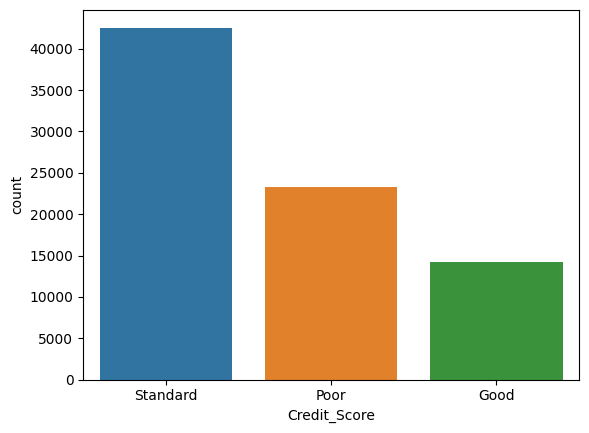

In [123]:
sns.countplot(data=fin_train,x='Credit_Score',palette='tab10')

<Axes: xlabel='count', ylabel='Occupation'>

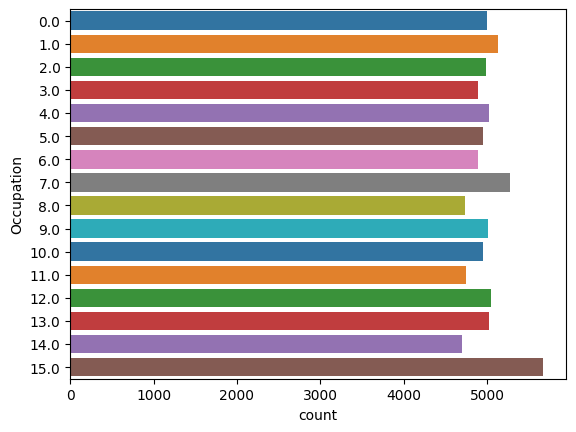

In [124]:
sns.countplot(data=fin_train,y='Occupation',palette='tab10')

<Axes: xlabel='Credit_Mix', ylabel='count'>

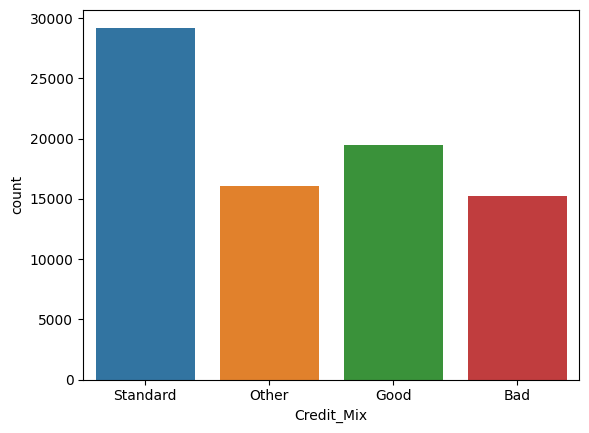

In [125]:
sns.countplot(data=fin_train,x='Credit_Mix',palette='tab10')

<Axes: xlabel='count', ylabel='Payment_Behaviour'>

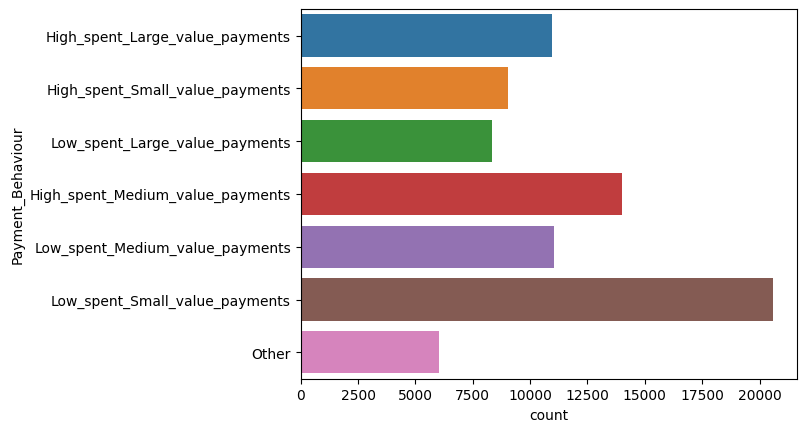

In [126]:
sns.countplot(data=fin_train,y='Payment_Behaviour',palette='tab10')

<Axes: xlabel='Payment_of_Min_Amount', ylabel='count'>

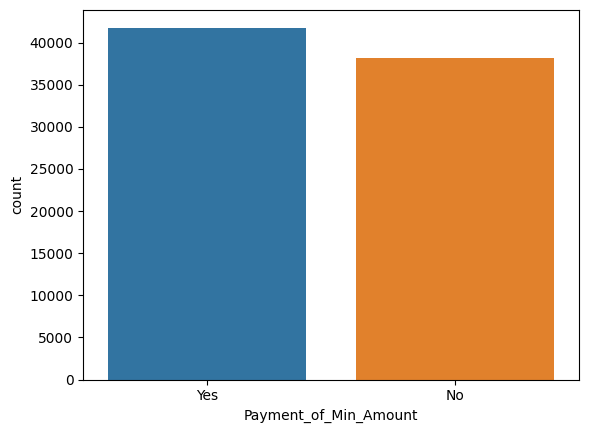

In [127]:
sns.countplot(data=fin_train,x='Payment_of_Min_Amount',palette='tab10')

<Axes: xlabel='Credit_Score', ylabel='count'>

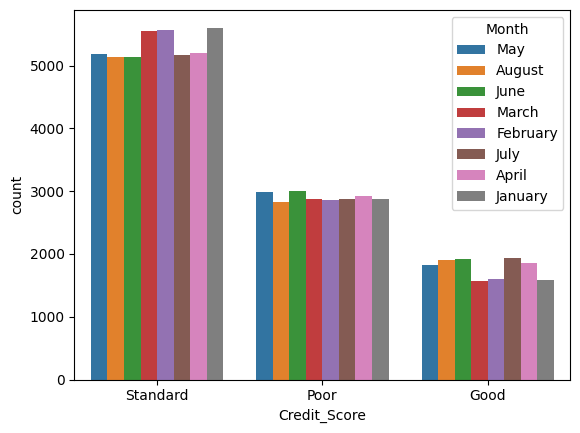

In [128]:
sns.countplot(data=fin_train,x='Credit_Score',palette='tab10',hue='Month')

<Axes: xlabel='Age', ylabel='Count'>

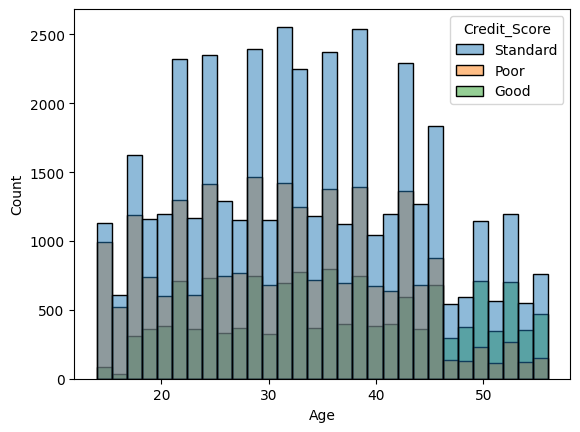

In [129]:
sns.histplot(data=fin_train, x='Age', hue='Credit_Score', bins=30)

<Axes: xlabel='Monthly_Inhand_Salary', ylabel='Count'>

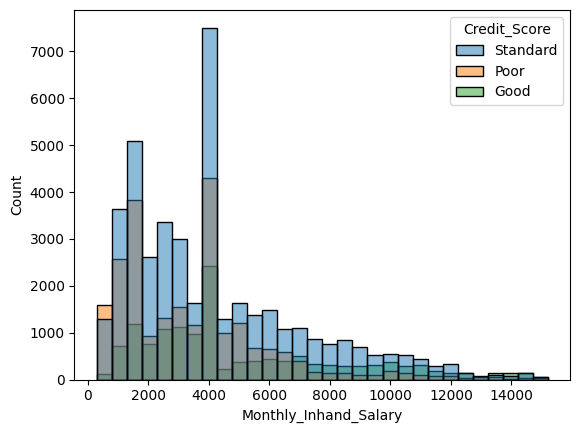

In [130]:
sns.histplot(data=fin_train, x='Monthly_Inhand_Salary', hue='Credit_Score', bins=30)

<Axes: xlabel='Num_Credit_Card', ylabel='Count'>

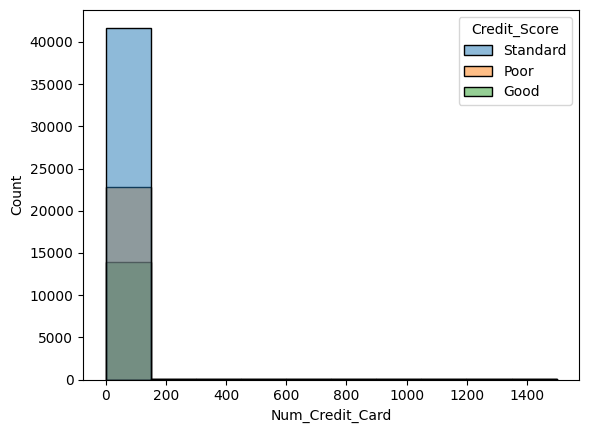

In [131]:
sns.histplot(data=fin_train, x='Num_Credit_Card', hue='Credit_Score',bins=10)

<Axes: xlabel='Credit_Score', ylabel='Delay_from_due_date'>

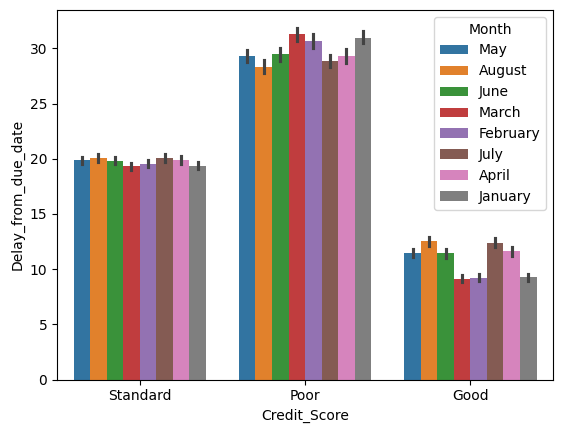

In [132]:
sns.barplot(data=fin_train,x='Credit_Score',y='Delay_from_due_date',hue='Month')

<Axes: xlabel='Credit_Score', ylabel='Num_of_Loan'>

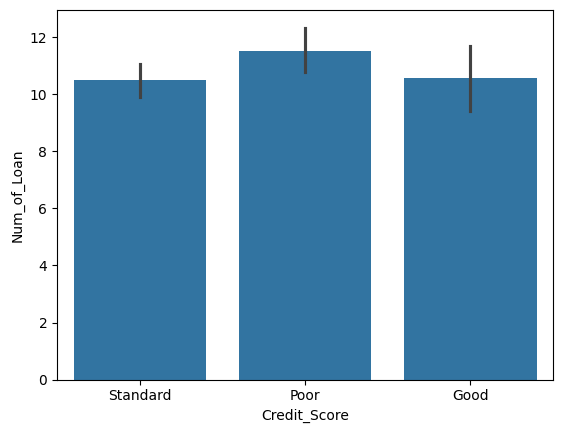

In [133]:
sns.barplot(data=fin_train,x='Credit_Score',y='Num_of_Loan')

<Axes: xlabel='Credit_Score', ylabel='Num_Bank_Accounts'>

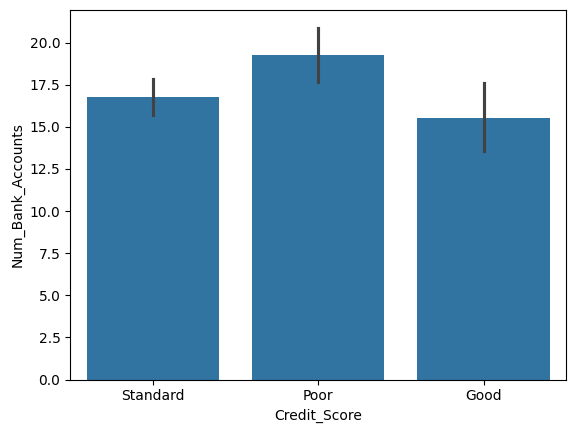

In [134]:
sns.barplot(data=fin_train,x='Credit_Score',y='Num_Bank_Accounts')

<Axes: xlabel='Age', ylabel='Monthly_Inhand_Salary'>

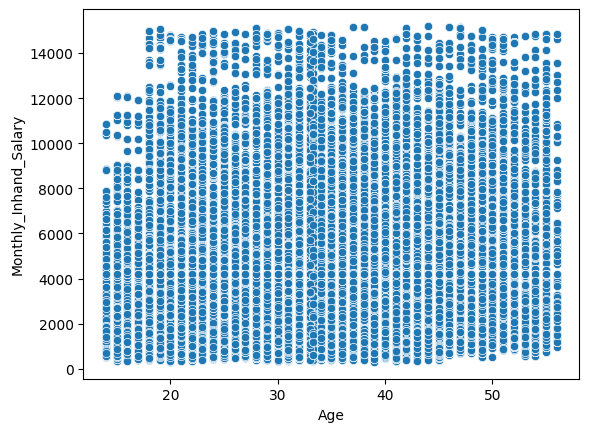

In [135]:
sns.scatterplot(data=fin_train,x='Age',y='Monthly_Inhand_Salary')

<Axes: xlabel='Num_Bank_Accounts', ylabel='Num_Credit_Card'>

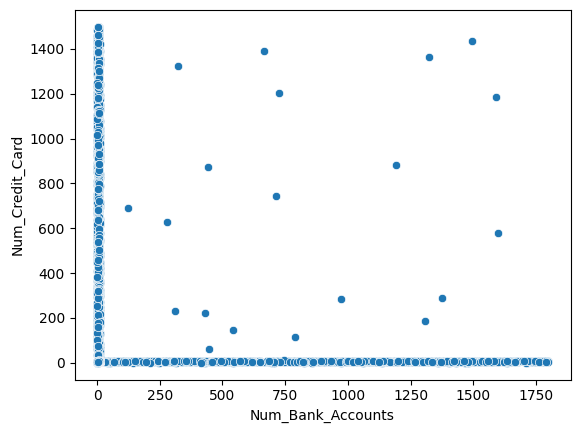

In [136]:
sns.scatterplot(data=fin_train,x='Num_Bank_Accounts',y='Num_Credit_Card')

<Axes: xlabel='Num_of_Loan', ylabel='Delay_from_due_date'>

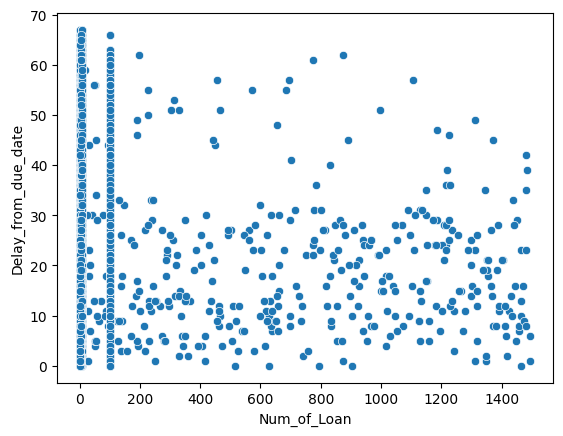

In [137]:
sns.scatterplot(data=fin_train,x='Num_of_Loan',y='Delay_from_due_date')

<Axes: xlabel='Amount_invested_monthly', ylabel='Count'>

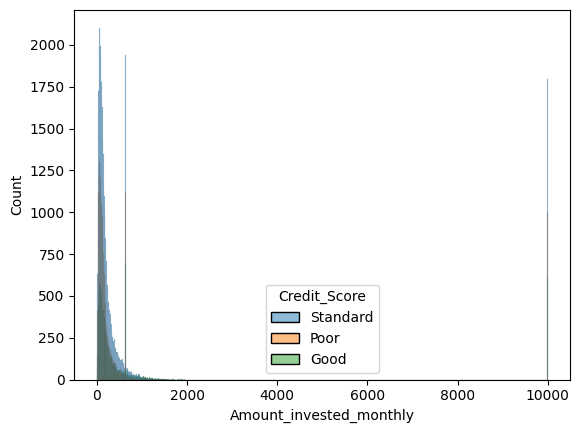

In [138]:
sns.histplot(data=fin_train,x='Amount_invested_monthly',hue='Credit_Score')

<Axes: xlabel='Credit_History_Age', ylabel='Count'>

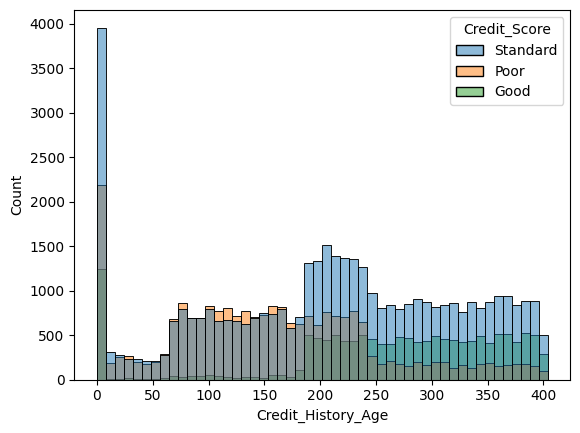

In [139]:
sns.histplot(data=fin_train,x='Credit_History_Age',hue='Credit_Score')

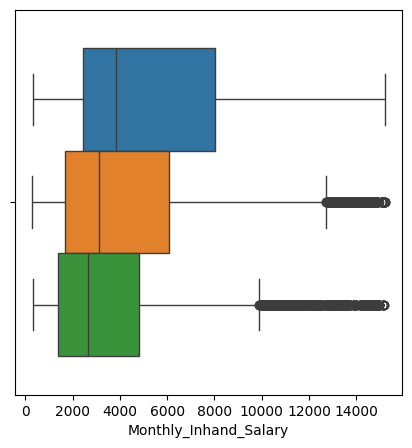

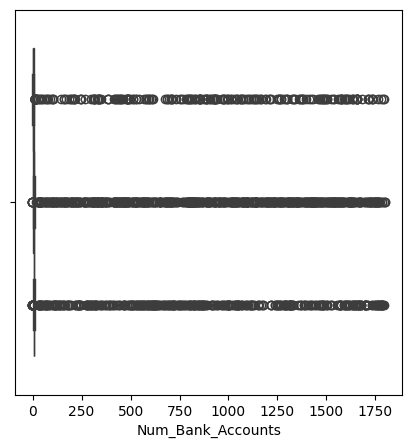

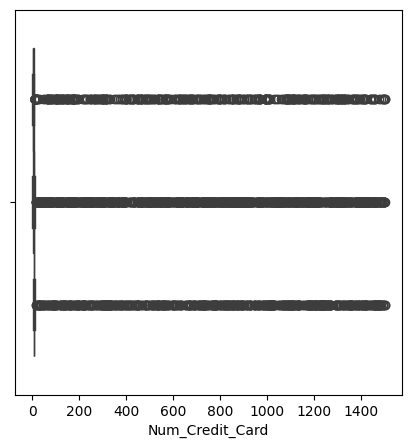

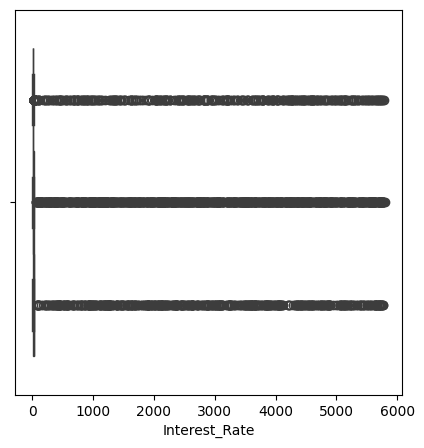

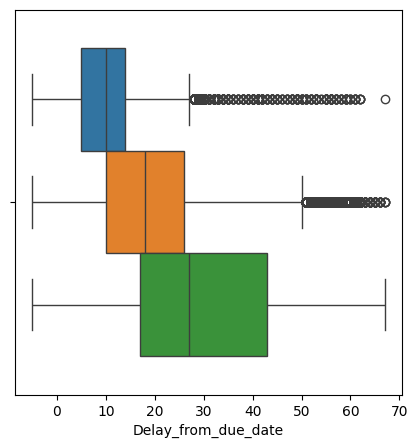

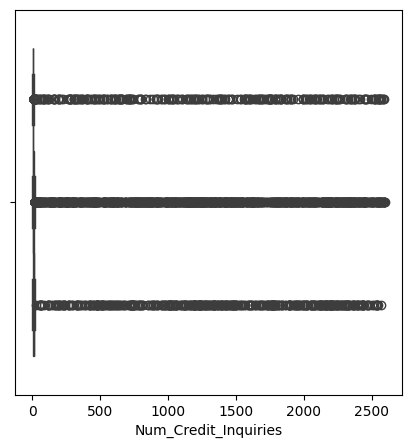

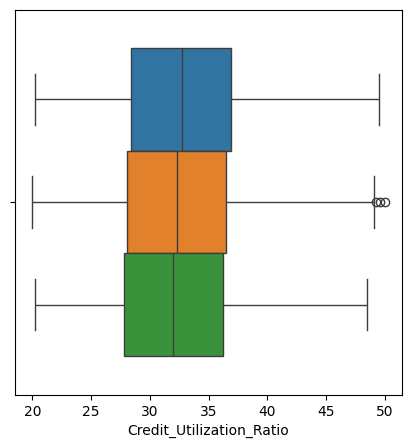

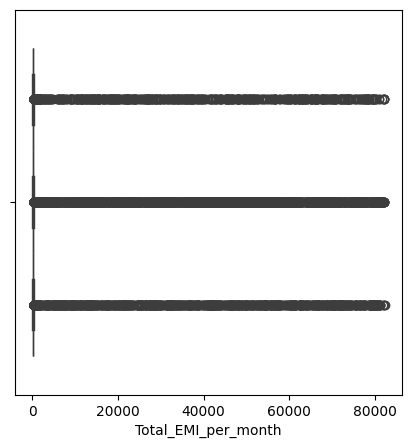

In [140]:
for col in train.select_dtypes('number').columns:
    plt.figure(figsize=(5, 5))
    ax=sns.boxplot(data=train,x=col,hue='Credit_Score')
    ax.legend_.remove()
    plt.show()

In [141]:
train['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [142]:
fin_train['Credit_Score'].replace({'Standard':1,'Poor':0,'Good':2},inplace=True)

In [143]:
fin_val['Credit_Score'].replace({'Standard':1,'Poor':0,'Good':2},inplace=True)

<Axes: >

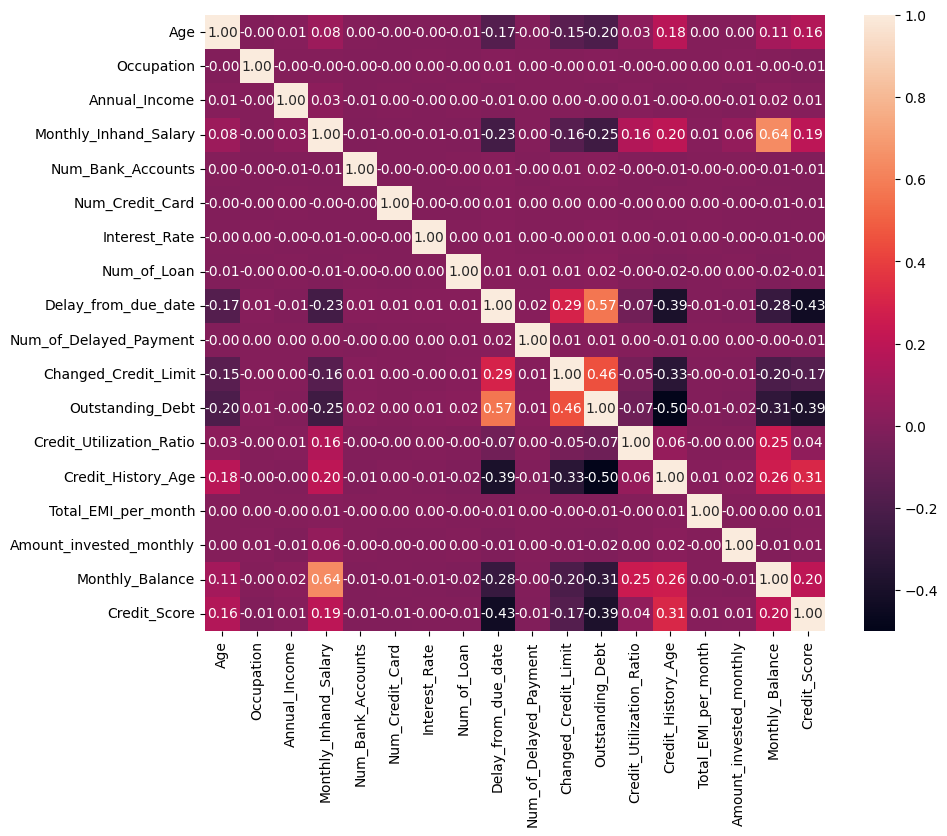

In [144]:
plt.figure(figsize=(10, 8))
sns.heatmap(fin_train.select_dtypes('number').corr(),annot=True,fmt=".2f")

# convert categorical values to numerical

In [145]:
categorical_columns = ['Credit_Mix','Payment_Behaviour','Payment_of_Min_Amount']

In [146]:
for col in categorical_columns:
    fin_train[col] = fin_train[col].astype(str)

In [147]:
fin_train['Occupation'].value_counts()

,count
Occupation,
15.0,5663
7.0,5268
1.0,5124
12.0,5047
4.0,5027
13.0,5021
9.0,5014
0.0,4999
2.0,4981


In [148]:
fin_train['Month'].unique()

array(['May', 'August', 'June', 'March', 'February', 'July', 'April',
       'January'], dtype=object)

In [149]:
fin_train['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3},inplace=True)

In [150]:
# Initialize OneHotEncoder
one_encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = one_encoder.fit_transform(fin_train[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded,
                          columns=one_encoder.get_feature_names_out(categorical_columns))




In [151]:
one_hot_df

,Credit_Mix_Bad,Credit_Mix_Good,Credit_Mix_Other,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
79996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
79997,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
79998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [152]:
fin_train.shape

(80000, 28)

In [153]:
fin_train=fin_train.drop(categorical_columns, axis=1)

# Outliers

In [154]:
def outlier_percentage_iqr(df):
    outlier_percentages = {}
    for column in fin_train.select_dtypes(include=['number']):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((fin_train[column] < lower_bound) | (fin_train[column] > upper_bound)).sum()
        outlier_percentages[column] = (outliers / len(train)) * 100
    return outlier_percentages

outlier_percentages = outlier_percentage_iqr(fin_train)
outlier_percentages


{'Month': 0.0,
 'Age': 0.0,
 'Occupation': 0.0,
 'Annual_Income': 2.226,
 'Monthly_Inhand_Salary': 3.527,
 'Num_Bank_Accounts': 1.055,
 'Num_Credit_Card': 1.825,
 'Interest_Rate': 1.614,
 'Num_of_Loan': 3.4979999999999998,
 'Delay_from_due_date': 3.2169999999999996,
 'Num_of_Delayed_Payment': 0.586,
 'Changed_Credit_Limit': 0.901,
 'Outstanding_Debt': 4.191000000000001,
 'Credit_Utilization_Ratio': 0.004,
 'Credit_History_Age': 0.0,
 'Total_EMI_per_month': 5.401,
 'Amount_invested_monthly': 6.554,
 'Monthly_Balance': 6.29,
 'Credit_Score': 0.0}

# feature Scaling

In [155]:
dropped_column=['ID','Customer_ID','Name','SSN','Type_of_Loan']

In [156]:
train_new=fin_train.drop(dropped_column, axis=1)

In [157]:
train_new.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
59428,5,41.0,11.0,70154.850,5696.237500,8,5,18,814,27,8,19.23,0.0,487.42,39.224627,252,92.888270,87.632538,629.102942,1
51959,8,54.0,0.0,29508.410,4190.984620,7,4,9,1,18,30,10.75,4.0,333.86,27.221135,237,16.547212,32.351596,448.704608,1
63188,5,19.0,14.0,31346.220,4190.984620,8,5,31,9,44,17,3.76,12.0,1795.98,33.204489,107,187.425136,82.924234,238.969130,1
99613,6,32.0,6.0,64901.370,5298.447500,3,5,20,0,15,30,2.94,3.0,442.06,33.682697,375,8323.000000,97.859913,691.984837,1
57804,5,32.0,12.0,7200.035,540.002917,8,8,18,3,60,17,8.51,11.0,2442.56,31.286252,170,13.723019,632.200029,294.975524,0


In [158]:
train_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 59428 to 92975
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     80000 non-null  int64  
 1   Age                       80000 non-null  float64
 2   Occupation                80000 non-null  float64
 3   Annual_Income             80000 non-null  float64
 4   Monthly_Inhand_Salary     80000 non-null  float64
 5   Num_Bank_Accounts         80000 non-null  int64  
 6   Num_Credit_Card           80000 non-null  int64  
 7   Interest_Rate             80000 non-null  int64  
 8   Num_of_Loan               80000 non-null  int64  
 9   Delay_from_due_date       80000 non-null  int64  
 10  Num_of_Delayed_Payment    80000 non-null  int64  
 11  Changed_Credit_Limit      80000 non-null  float64
 12  Num_Credit_Inquiries      80000 non-null  object 
 13  Outstanding_Debt          80000 non-null  float64
 14  Credit_

In [159]:
train_target=train_new['Credit_Score']

In [160]:
new_train=train_new[['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']]


In [161]:
scaler=QuantileTransformer()
scaled_new_train=scaler.fit_transform(new_train)

In [162]:
data_2=pd.DataFrame(scaled_new_train,columns=new_train.columns)
data_2.head()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Outstanding_Debt
0,0.769511,0.817818,0.410410,0.657658,0.997355,0.724725,0.184184,0.894217,0.597630,0.300211,0.864548,0.210586
1,0.595596,0.688689,0.246747,0.312813,0.160160,0.504505,0.956957,0.591925,0.157157,0.051088,0.728985,0.140613
2,0.595596,0.817818,0.410410,0.924424,0.938438,0.894895,0.628629,0.171171,0.801643,0.280798,0.140847,0.727662
3,0.747870,0.186687,0.410410,0.735235,0.000000,0.420921,0.956957,0.131632,0.972723,0.342118,0.894546,0.186186
4,0.009302,0.817818,0.856857,0.657658,0.442442,0.984484,0.628629,0.428929,0.140472,0.894895,0.354257,0.822122


In [163]:
df1_reset = data_2.reset_index(drop=True)
df2_reset = one_hot_df.reset_index(drop=True)

# Concatenate or merge them as needed, for example:
new_data = pd.concat([df1_reset, df2_reset], axis=1)

new_data

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,0.769511,0.817818,0.410410,0.657658,0.997355,0.724725,0.184184,0.894217,0.597630,0.300211,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.595596,0.688689,0.246747,0.312813,0.160160,0.504505,0.956957,0.591925,0.157157,0.051088,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.595596,0.817818,0.410410,0.924424,0.938438,0.894895,0.628629,0.171171,0.801643,0.280798,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.747870,0.186687,0.410410,0.735235,0.000000,0.420921,0.956957,0.131632,0.972723,0.342118,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.009302,0.817818,0.856857,0.657658,0.442442,0.984484,0.628629,0.428929,0.140472,0.894895,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0.473146,0.186687,0.109109,0.992068,0.000000,0.095095,0.339840,0.250250,0.987227,0.697337,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
79996,0.249853,0.000000,0.751251,0.312813,0.590090,0.530531,0.234735,0.027027,0.426298,0.263121,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
79997,0.491264,0.817818,0.856857,0.956957,0.701702,0.724725,0.574074,0.940632,0.935766,0.569755,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
79998,0.231388,0.066567,0.109109,0.403403,0.160160,0.052052,0.059560,0.433524,0.125858,0.502388,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [164]:
fin_data=pd.DataFrame(train_new[['Age','Month','Occupation','Credit_History_Age']])
fin_data

,Age,Month,Occupation,Credit_History_Age
59428,41.0,5,11.0,252
51959,54.0,8,0.0,237
63188,19.0,5,14.0,107
99613,32.0,6,6.0,375
57804,32.0,5,12.0,170
...,...,...,...,...
89460,44.0,5,10.0,271
60620,29.0,5,12.0,326
34086,24.0,7,3.0,85
58067,44.0,4,7.0,384


In [165]:
fin_data.reset_index(drop=True,inplace=True)
new_data.reset_index(drop=True,inplace=True)
final_data=pd.concat([fin_data,new_data],axis=1)
final_data.head()

,Age,Month,Occupation,Credit_History_Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,41.0,5,11.0,252,0.769511,0.817818,0.410410,0.657658,0.997355,0.724725,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,54.0,8,0.0,237,0.595596,0.688689,0.246747,0.312813,0.160160,0.504505,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,19.0,5,14.0,107,0.595596,0.817818,0.410410,0.924424,0.938438,0.894895,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,32.0,6,6.0,375,0.747870,0.186687,0.410410,0.735235,0.000000,0.420921,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,32.0,5,12.0,170,0.009302,0.817818,0.856857,0.657658,0.442442,0.984484,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [166]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 80000 non-null  float64
 1   Month                                               80000 non-null  int64  
 2   Occupation                                          80000 non-null  float64
 3   Credit_History_Age                                  80000 non-null  int64  
 4   Monthly_Inhand_Salary                               80000 non-null  float64
 5   Num_Bank_Accounts                                   80000 non-null  float64
 6   Num_Credit_Card                                     80000 non-null  float64
 7   Interest_Rate                                       80000 non-null  float64
 8   Num_of_Loan                                         80000 non-null  float64


# Feature selection

In [167]:
# from correlation matrix
features=final_data[['Age', 'Month', 'Occupation', 'Credit_History_Age',
                    'Monthly_Inhand_Salary','Delay_from_due_date','Monthly_Balance',
                     'Outstanding_Debt','Changed_Credit_Limit','Num_of_Loan', 'Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Credit_Mix_Bad']]

# Prepare Test Set

Apply the data transformations you used on the training set to the test set.

**Important Note:** DO NOT use `fit` on the test set.

In [168]:
fin_val['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3},inplace=True)

In [169]:
fin_val.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [170]:
fin_val.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,2025
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [172]:
one_hot_encoded_val = one_encoder.transform(fin_val[categorical_columns])
one_hot_df_val = pd.DataFrame(one_hot_encoded_val,
                          columns=one_encoder.get_feature_names_out(categorical_columns))




In [173]:
new_val=fin_val[['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']]


In [174]:
new_vall=['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']


In [175]:
vall=fin_val.drop(new_vall,axis=1)

In [176]:
vall=vall[['Age','Month','Occupation','Credit_History_Age']]
vall.isna().sum()

,0
Age,0
Month,0
Occupation,0
Credit_History_Age,0


In [177]:
scaled_new_val=scaler.transform(new_val)

In [178]:
data_2_val=pd.DataFrame(scaled_new_val,columns=new_val.columns)
data_2_val.head()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Outstanding_Debt
0,0.737831,0.959459,0.856857,0.924424,0.852853,0.913413,0.873874,0.424424,0.860871,0.843841,0.008138,0.810737
1,0.595596,0.306807,0.246747,0.403403,0.852853,0.579580,0.787788,0.758759,0.373896,0.326782,0.150337,0.500056
2,0.084688,0.959459,0.952953,0.872873,0.701702,0.651652,0.734234,0.564064,0.384980,0.433481,0.114335,0.954367
3,0.906822,0.108609,0.996023,0.059560,0.975976,0.315315,0.059560,0.530197,0.750040,0.579104,0.936671,0.179727
4,0.499768,0.907407,0.952953,0.735235,0.701702,0.872372,0.827828,0.937245,0.986943,0.407275,0.478954,0.980040


In [179]:
df1_reset = data_2_val.reset_index(drop=True)
df2_reset = one_hot_df_val.reset_index(drop=True)
new_val = pd.concat([df1_reset, df2_reset], axis=1)

new_val

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,0.737831,0.959459,0.856857,0.924424,0.852853,0.913413,0.873874,0.424424,0.860871,0.843841,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.595596,0.306807,0.246747,0.403403,0.852853,0.579580,0.787788,0.758759,0.373896,0.326782,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.084688,0.959459,0.952953,0.872873,0.701702,0.651652,0.734234,0.564064,0.384980,0.433481,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.906822,0.108609,0.996023,0.059560,0.975976,0.315315,0.059560,0.530197,0.750040,0.579104,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.499768,0.907407,0.952953,0.735235,0.701702,0.872372,0.827828,0.937245,0.986943,0.407275,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.595596,0.000000,0.586086,0.000000,0.000000,0.252252,0.234735,0.347347,0.000000,0.894895,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
19996,0.825672,0.186687,0.246747,0.485986,0.778779,0.315315,0.734234,0.369369,0.914698,1.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
19997,0.905559,0.429930,0.410410,0.358358,0.000000,0.651652,0.234735,0.788742,0.000000,0.940197,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
19998,0.850167,0.557057,0.751251,0.844344,0.778779,0.998999,0.787788,0.133467,0.950593,0.835682,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [180]:
vall.shape

(20000, 4)

In [181]:
new_val.shape

(20000, 25)

In [182]:
new_val = new_val.reset_index(drop=True)
vall = vall.reset_index(drop=True)
new_val[['Age','Month','Occupation','Credit_History_Age']]=vall[['Age','Month','Occupation','Credit_History_Age']]
new_val.isna().sum()


,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Total_EMI_per_month,0
Amount_invested_monthly,0


In [183]:
new_val.shape

(20000, 29)

In [184]:
val=new_val[['Age', 'Month', 'Occupation', 'Credit_History_Age',
                    'Monthly_Inhand_Salary','Delay_from_due_date','Monthly_Balance',
                     'Outstanding_Debt','Changed_Credit_Limit','Num_of_Loan', 'Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Credit_Mix_Bad']]

In [185]:
val.isna().sum()

,0
Age,0
Month,0
Occupation,0
Credit_History_Age,0
Monthly_Inhand_Salary,0
Delay_from_due_date,0
Monthly_Balance,0
Outstanding_Debt,0
Changed_Credit_Limit,0
Num_of_Loan,0


----------------------

# `05` Linear Support Vector Machine Classifier

Using `sklearn` implementation of linear support vector machine classifiers to model the data.

Hint: Look for `sklearn.svm.LinearSVC` class.

## `i` Baseline Model Training

Initializing the model with initial parameters, fitting it to the training data, and get a baseline model.

Use:
- `random_state` $= 1234$

In [186]:

SV=LinearSVC(random_state=1234,class_weight='balanced')
SV.fit(features,train_target)

LinearSVC(class_weight='balanced', random_state=1234)

## `ii` Model Evaluation

Evaluate the baseline model performance using classification metrics, e.g. **Accuracy**, **Precision**, $F_1 \space Score$, **Confusion Matrix** etc.

Which metric is more reliable?

In [187]:
SV.score(features,train_target)

0.6277125

In [188]:
y_pred=SV.predict(val)

In [189]:
val_target=fin_val['Credit_Score']

In [190]:

accuracy_score(val_target,y_pred)

0.6279

In [191]:
precision_score(val_target,y_pred,average='weighted')

0.6477436860022796

In [192]:
f1_score(val_target,y_pred,average='weighted')

0.6313543583928402

In [193]:
confusion_matrix(val_target,y_pred)

array([[3458, 1474,  827],
       [2288, 6497, 1824],
       [ 115,  914, 2603]])

<Axes: >

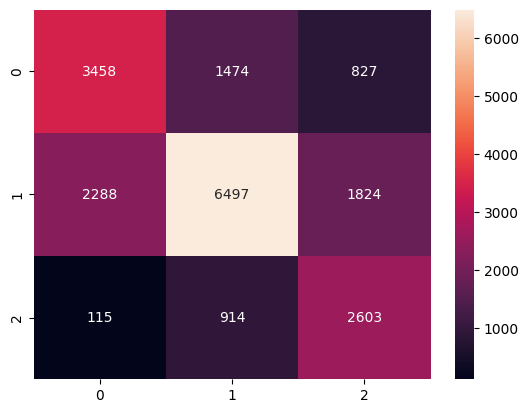

In [194]:
sns.heatmap(confusion_matrix(val_target,y_pred),annot=True,fmt="d")

----------------------

# `06` Kernelized Support Vector Machine Classifier

Using `sklearn` implementation of kernelized support vector machine classifiers to model the data.

Hint: Look for `sklearn.svm.SVC` class.

In [ ]:
SV=SVC(C=50,random_state=1234,class_weight='balanced')
SV.fit(features,train_target)


In [ ]:
SV.score(features,train_target)

In [ ]:
y_pred=SV.predict(val)

In [ ]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.6118
precision_score= 0.6768330176571097
f1_score= 0.613833965311299


## `i` Baseline Model Training

Initializing the model with initial parameters, fitting it to the training data, and get a baseline model.

Use:
- `random_state` $= 1234$
- `kernel` = 'linear'

In [ ]:
#from sklearn.decomposition import PCA

#pca = PCA(n_components=10)
#features_reduced = pca.fit_transform(features)


In [ ]:
features = features[:5000]
train_target = train_target[:5000]


In [ ]:
SV_Linear=SVC(kernel='linear',random_state=1234,class_weight='balanced')
SV_Linear.fit(features,train_target)


SVC(class_weight='balanced', kernel='linear', random_state=1234)

In [ ]:
SV_Linear.score(features,train_target)

0.6226

In [ ]:
y_pred=SV_Linear.predict(val)

## `ii` Model Evaluation

Evaluate the baseline model performance using classification metrics, e.g. **Accuracy**, **Precision**, $F_1 \space Score$, **Confusion Matrix** etc.

`Q` Which metric is more reliable?
`Q` Compare the results to those of `sklearn.svm.LinearSVC` class. Also, is there a difference in the training time?

In [ ]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))
print('all_scores=',classification_report(val_target,y_pred))


accuracy_score= 0.6115
precision_score= 0.6651104536227507
f1_score= 0.6144847287856384
all_scores=               precision    recall  f1-score   support

           0       0.59      0.61      0.60      5759
           1       0.78      0.53      0.63     10609
           2       0.45      0.85      0.59      3632

    accuracy                           0.61     20000
   macro avg       0.61      0.66      0.61     20000
weighted avg       0.67      0.61      0.61     20000



## `iii` Kernelization Mode: On

Let's try the both `poly` and `rbf` kernels. Use default $C, \gamma, \space and/or \space degree$ parameter(s) for simplicity if you want. Does kernelization make the model better?

Which of the two kernels performs better?

In [ ]:
SV_poly=SVC(kernel='poly',C=100,random_state=1234,class_weight='balanced')
SV_poly.fit(features,train_target)


SVC(C=100, class_weight='balanced', kernel='poly', random_state=1234)

In [ ]:
SV_poly.score(features,train_target)

0.5588

In [ ]:
y_pred=SV_poly.predict(val)
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))
print('all_scores=',classification_report(val_target,y_pred))


accuracy_score= 0.54835
precision_score= 0.6605853406147758
f1_score= 0.5373191897680051
all_scores=               precision    recall  f1-score   support

           0       0.45      0.80      0.58      5759
           1       0.83      0.36      0.50     10609
           2       0.48      0.70      0.57      3632

    accuracy                           0.55     20000
   macro avg       0.59      0.62      0.55     20000
weighted avg       0.66      0.55      0.54     20000



## using **rbf**

In [ ]:
SV_rbf=SVC(kernel='rbf',C=1000,random_state=1234,class_weight='balanced')
SV_rbf.fit(features,train_target)


SVC(C=1000, class_weight='balanced', random_state=1234)

In [ ]:
SV_rbf.score(features,train_target)

0.6274

In [ ]:
y_pred=SV_rbf.predict(val)
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))
print('all_scores=',classification_report(val_target,y_pred))


accuracy_score= 0.60975
precision_score= 0.6751288616096534
f1_score= 0.6115291992241778
all_scores=               precision    recall  f1-score   support

           0       0.59      0.67      0.63      5759
           1       0.80      0.50      0.61     10609
           2       0.45      0.85      0.59      3632

    accuracy                           0.61     20000
   macro avg       0.61      0.67      0.61     20000
weighted avg       0.68      0.61      0.61     20000



## `iv` Tuning Hyperparameters

Try different  $C, \gamma, \space and/or \space degree$ values and evaluate. What is the best hyperparamters value combination?

Remember that $alpha=\frac{1}{C}$ which means less regularization for higher $C$ values.

`Hint:` Make sure to tune only relevant hyperparameters per kernel (e.g., don't tune different values for `degree` while using `rbf` kernel)

`Note:` You can tune other parameters as you see fit (but make sure you elaborate your reasoning.

Hint: You might want to use `sklearn.model_selection.RandomizedSearchCV` or `sklearn.model_selection.GridSearchCV` classes.

In [ ]:
params = [
    {
        'kernel': ['linear'],
        'C': [ 0.1, 1, 10, 100, 1000]
    },
    {
        'kernel': ['poly'],
        'degree': [2, 3, 4],
        'coef0': [0.01, 1, 10, 50],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto', 0.01, 1, 2],
        'C': [0.1, 1, 10, 100, 1000]
    }
]
random_svc=RandomizedSearchCV(SVC(),
    params,
    cv=3,
    verbose=3
                              )
random_svc.fit(features,train_target)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END C=1, coef0=0.01, degree=3, kernel=poly;, score=0.529 total time=   1.1s
[CV 2/3] END C=1, coef0=0.01, degree=3, kernel=poly;, score=0.528 total time=   1.2s
[CV 3/3] END C=1, coef0=0.01, degree=3, kernel=poly;, score=0.529 total time=   1.1s
[CV 1/3] END C=1000, coef0=10, degree=3, kernel=poly;, score=0.636 total time= 1.6min
[CV 2/3] END C=1000, coef0=10, degree=3, kernel=poly;, score=0.631 total time= 1.6min
[CV 3/3] END C=1000, coef0=10, degree=3, kernel=poly;, score=0.632 total time= 1.2min
[CV 1/3] END C=0.1, coef0=1, degree=4, kernel=poly;, score=0.529 total time=   0.9s
[CV 2/3] END C=0.1, coef0=1, degree=4, kernel=poly;, score=0.528 total time=   0.9s
[CV 3/3] END C=0.1, coef0=1, degree=4, kernel=poly;, score=0.529 total time=   0.9s
[CV 1/3] END C=1, coef0=10, degree=2, kernel=poly;, score=0.527 total time=   0.9s
[CV 2/3] END C=1, coef0=10, degree=2, kernel=poly;, score=0.528 total time=   1.2s
[CV 3/3]

RandomizedSearchCV(cv=3, estimator=SVC(),
                   param_distributions=[{'C': [0.1, 1, 10, 100, 1000],
                                         'kernel': ['linear']},
                                        {'C': [0.001, 0.01, 0.1, 1, 10, 100,
                                               1000],
                                         'coef0': [0.01, 1, 10, 50],
                                         'degree': [2, 3, 4],
                                         'kernel': ['poly']},
                                        {'C': [0.1, 1, 10, 100, 1000],
                                         'gamma': ['scale', 'auto', 0.01, 1, 2],
                                         'kernel': ['rbf']}],
                   verbose=3)

In [ ]:
random_svc.best_estimator_

SVC(C=1000, coef0=10, kernel='poly')

In [ ]:
random_svc.score(features,train_target)

0.6502

In [ ]:
y_pred=random_svc.predict(val)
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))
print('all_scores=',classification_report(val_target,y_pred))


accuracy_score= 0.6304
precision_score= 0.633724696498605
f1_score= 0.6289073869247209
all_scores=               precision    recall  f1-score   support

           0       0.62      0.50      0.55      5759
           1       0.68      0.70      0.69     10609
           2       0.52      0.64      0.57      3632

    accuracy                           0.63     20000
   macro avg       0.61      0.61      0.60     20000
weighted avg       0.63      0.63      0.63     20000



------------------

# `07` Generalization Error

Now that we have tuned our solution, to an *extent*, we need to test for a final time on the held out test set.

In [ ]:
test.head()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

In [ ]:
test['Age'] = test['Age'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
test['Age']=test['Age'].astype(int)

In [ ]:
test['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3},inplace=True)

In [ ]:
test['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3,'September':9,'December':12,'October':10,'November':11},inplace=True)

In [ ]:
test['Month'].unique()

array([ 9, 10, 11, 12])

In [ ]:
test['Occupation'] = test['Occupation'].replace("_______", np.nan)


In [ ]:
test['Occupation'].replace({'Mechanic':0, 'Teacher':4, 'Engineer':5, 'Manager':6, 'Accountant':7,
       'Developer':8, 'Entrepreneur':9, 'Journalist':10, 'Doctor':11, 'Musician':12,
       'Writer':13, 'Scientist':14, 'Lawyer':15, 'Media_Manager':16, 'Architect':17},inplace=True)

In [ ]:
test['Occupation']=Occup_impute.transform(test[['Occupation']])

In [ ]:
test['Credit_History_Age'].fillna('Unknown',inplace=True)
history_age = []
for i in range(test.shape[0]):
    if ('Years and') in test['Credit_History_Age'].values[i]:
        splitted = test['Credit_History_Age'].values[i].split('Years and')
        years = int(splitted[0].strip())
        months = int(splitted[1].replace('Months', ''))
        history_age.append((years * 12) + months)
    else:
        history_age.append(0)

test['Credit_History_Age'] = history_age

In [ ]:
test['Monthly_Inhand_Salary'].fillna(fin_train['Monthly_Inhand_Salary'].mean(),inplace=True)

In [ ]:
test['Delay_from_due_date'] = test['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

In [ ]:
test['Monthly_Balance']=test['Monthly_Balance'].apply(lambda x:'nan' if x=='__-333333333333333333333333333__' else x)
test['Monthly_Balance']=test['Monthly_Balance'].astype(float)
test['Monthly_Balance'].fillna(fin_train['Monthly_Balance'].mean(),inplace=True)


In [ ]:
test['Outstanding_Debt'] = test['Outstanding_Debt'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
test['Outstanding_Debt']=test['Outstanding_Debt'].astype(float)


In [ ]:
test['Changed_Credit_Limit']=test['Changed_Credit_Limit'].apply(lambda x:'nan' if x=='_' else x)
test['Changed_Credit_Limit'] = imputer.transform(test[['Changed_Credit_Limit']])
test['Changed_Credit_Limit']=test['Changed_Credit_Limit'].astype(float)



In [ ]:
test['Num_of_Loan'] = test['Num_of_Loan'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
test['Num_of_Loan']=test['Num_of_Loan'].astype(int)

In [ ]:
test['Payment_of_Min_Amount']=test['Payment_of_Min_Amount'].apply(lambda x: 'No' if x=='NM' else x)

In [ ]:
test['Credit_Mix']=test['Credit_Mix'].apply(lambda x:'Other' if x=='_' else x )

In [ ]:
test['Payment_Behaviour']=test['Payment_Behaviour'].apply(lambda x:'Other' if x=='!@9#%8' else x)

In [ ]:
one_hot_encoded = one_encoder.transform(test[categorical_columns])
one_hot_df_test = pd.DataFrame(one_hot_encoded,
                          columns=one_encoder.get_feature_names_out(categorical_columns))



In [ ]:
new_test=test[['Age', 'Month', 'Occupation', 'Credit_History_Age',
                    'Monthly_Inhand_Salary','Delay_from_due_date','Monthly_Balance',
                     'Outstanding_Debt','Changed_Credit_Limit','Num_of_Loan']]
one_test=one_hot_df_test[['Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Credit_Mix_Bad']]

new_test.reset_index(drop=True,inplace=True)
one_test.reset_index(drop=True,inplace=True)
final_test=pd.concat([new_test,one_test],axis=1)
final_test.head()

,Age,Month,Occupation,Credit_History_Age,Monthly_Inhand_Salary,Delay_from_due_date,Monthly_Balance,Outstanding_Debt,Changed_Credit_Limit,Num_of_Loan,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Credit_Mix_Bad
0,23,9,14.000000,273,1824.843333,3,186.266702,809.98,11.27,4,1.0,0.0,0.0,1.0,0.0
1,24,10,14.000000,274,1824.843333,3,361.444004,809.98,13.27,4,1.0,0.0,0.0,1.0,0.0
2,24,11,14.000000,0,1824.843333,1,264.675446,809.98,12.27,4,1.0,0.0,0.0,1.0,0.0
3,24,12,14.000000,276,4190.984620,4,343.826873,809.98,11.27,4,1.0,0.0,0.0,1.0,0.0
4,28,9,7.526262,327,3037.986667,3,485.298434,605.03,5.42,1,1.0,0.0,0.0,1.0,0.0


In [ ]:
final_test.isna().sum()

,0
Age,0
Month,0
Occupation,0
Credit_History_Age,0
Monthly_Inhand_Salary,0
Delay_from_due_date,0
Monthly_Balance,0
Outstanding_Debt,0
Changed_Credit_Limit,0
Num_of_Loan,0


In [ ]:
output=random_svc.predict(final_test)

In [ ]:
output

array([1, 1, 1, ..., 1, 1, 1])

-----------------------------

# `Bonus` Better Flow

For the model to be production-ready, we need to integrate it into a pipeline along with the data preparation flow.

Hint: Look up `sklearn.pipeline.Pipeline` class.

In [ ]:
sgd_svm = Pipeline([
    ('model', SGDClassifier(
        loss='hinge',
        random_state=1234,
        learning_rate='adaptive',
        eta0=0.001,
        class_weight="balanced"
    ))
])


In [ ]:
cv_scores = cross_val_score(sgd_svm, features, train_target, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

Cross-validation scores: [0.639 0.618 0.619 0.625 0.63 ]
Mean accuracy: 0.6262000000000001


In [ ]:
sgd_svm.fit(features,train_target)

Pipeline(steps=[('model',
                 SGDClassifier(class_weight='balanced', eta0=0.001,
                               learning_rate='adaptive', random_state=1234))])

In [ ]:
sgd_svm.score(features,train_target)

0.6248

In [ ]:
y_pred=sgd_svm.predict(val)

In [ ]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.6136
precision_score= 0.6339201472075937
f1_score= 0.6168254902099881


----------------------------------------------

$$ Wish \space you \space all \space the \space best \space ♡ $$
$$ Abdelrahman \space Eid $$